# 🛍️ Customer Segmentation with K-Means Clustering

---

## 📌 Project Overview

This project applies **K-Means Clustering** — an unsupervised machine learning algorithm — to segment mall customers based on their **Annual Income** and **Spending Score**.

By identifying distinct customer groups, businesses can craft **targeted marketing strategies** that improve customer engagement and overall satisfaction.

---

## 🔄 Workflow

1. Load & explore the dataset  
2. Preprocess the data  
3. Find the optimal number of clusters using the **Elbow Method**  
4. Train the K-Means model  
5. Visualize the resulting customer segments  

---

## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 Step 2: Load & Explore the Dataset

The dataset contains information about **200 mall customers** with the following features:

| Column | Description |
|---|---|
| `CustomerID` | Unique identifier for each customer |
| `Gender` | Gender of the customer |
| `Age` | Age of the customer |
| `Annual Income (k$)` | Annual income in thousands of dollars |
| `Spending Score (1-100)` | Score assigned based on spending behavior |

In [2]:
# Load dataset — update path if needed
df = pd.read_csv('../data/Mall_Customers.csv')

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head()

Dataset Shape: 200 rows × 5 columns



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Dataset info
print("📋 Dataset Info:")
print("-" * 40)
df.info()

📋 Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# Statistical summary
print("📊 Statistical Summary:")
df.describe()

📊 Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


---
## 🔍 Step 3: Data Preprocessing

Check for missing values and select the relevant features for clustering.

In [5]:
# Check for missing values
print("🔍 Missing Values per Column:")
print(df.isnull().sum())
print("\n✅ No missing values found!" if df.isnull().sum().sum() == 0 else "\n⚠️ Missing values detected!")

🔍 Missing Values per Column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

✅ No missing values found!


In [6]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print(f"Feature matrix shape: {X.shape}")
print("Features selected: Annual Income (k$) and Spending Score (1-100)")

Feature matrix shape: (200, 2)
Features selected: Annual Income (k$) and Spending Score (1-100)


---
## 📈 Step 4: Exploratory Data Analysis (EDA)

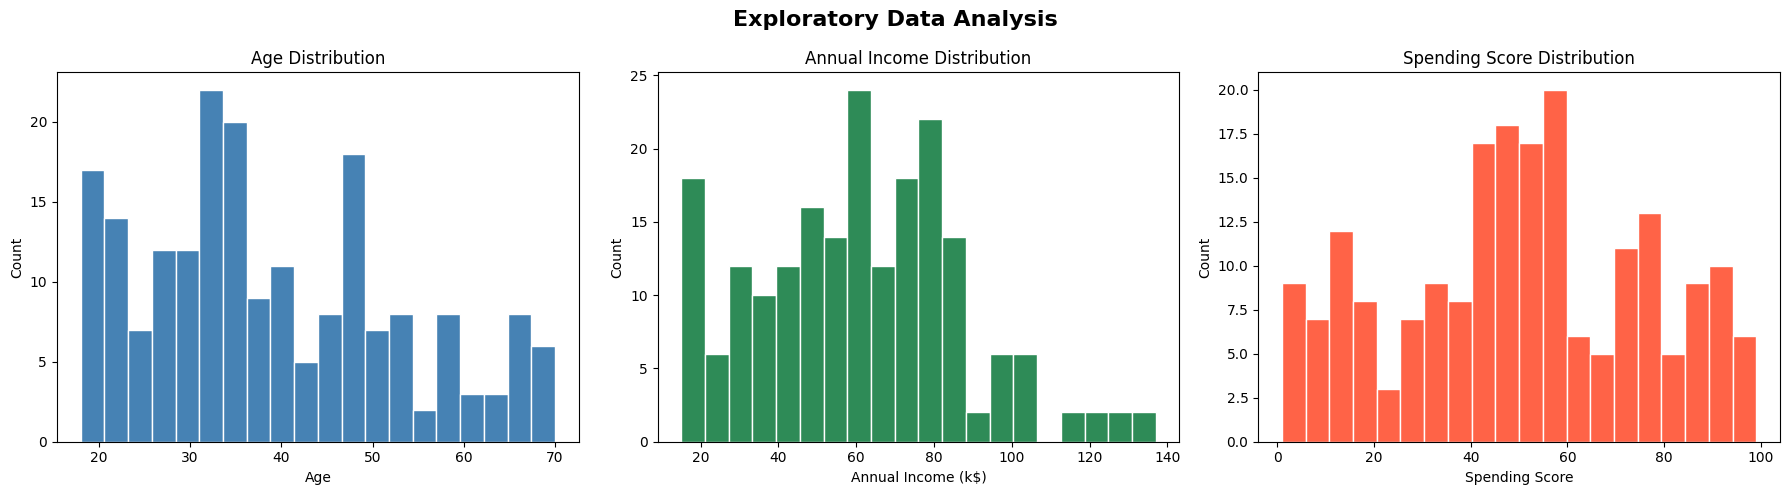

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Age distribution
axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Annual Income distribution
axes[1].hist(df['Annual Income (k$)'], bins=20, color='seagreen', edgecolor='white')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Count')

# Spending Score distribution
axes[2].hist(df['Spending Score (1-100)'], bins=20, color='tomato', edgecolor='white')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../images/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

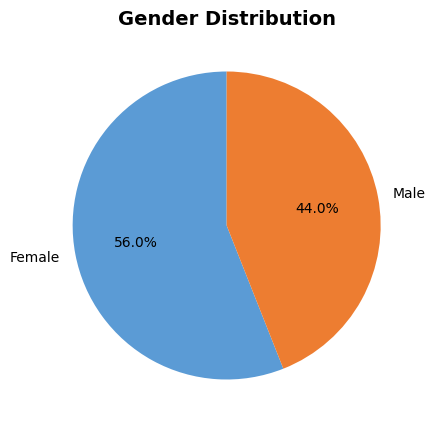

In [8]:
# Gender breakdown
plt.figure(figsize=(5, 5))
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#5b9bd5', '#ed7d31'], startangle=90)
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.savefig('../images/gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔧 Step 5: Finding Optimal Clusters — The Elbow Method

The **Elbow Method** plots the **Within-Cluster Sum of Squares (WCSS)** for different values of *k*.
The "elbow" — where the rate of decrease slows sharply — indicates the optimal number of clusters.

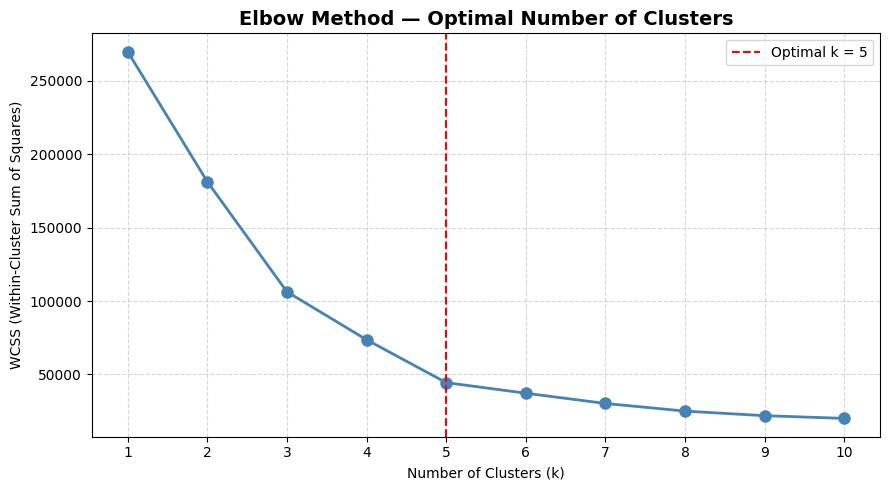

📌 The elbow appears at k = 5, indicating 5 optimal clusters.


In [9]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', linewidth=2, color='steelblue', markersize=8)
plt.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Optimal k = 5')
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../images/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 The elbow appears at k = 5, indicating 5 optimal clusters.")

---
## 🤖 Step 6: Training the K-Means Model

We train the K-Means model with **k = 5**, using `k-means++` initialization for better convergence.

In [10]:
# Train K-Means with optimal k = 5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
Y = kmeans.fit_predict(X)

# Add cluster labels to the dataframe
df['Cluster'] = Y + 1  # 1-indexed for readability

print("✅ K-Means model trained successfully!")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

✅ K-Means model trained successfully!

Cluster distribution:
Cluster
1    81
2    39
3    22
4    35
5    23
Name: count, dtype: int64


---
## 📊 Step 7: Visualizing the Customer Segments

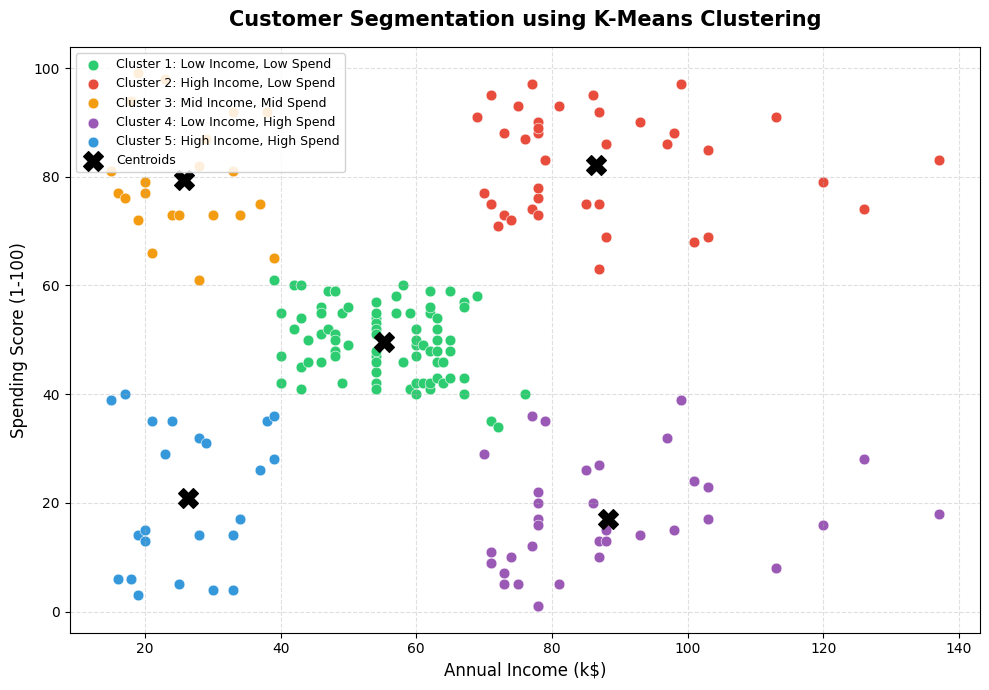

In [11]:
# Cluster colors and labels
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#3498db']
cluster_labels = [
    'Cluster 1: Low Income, Low Spend',
    'Cluster 2: High Income, Low Spend',
    'Cluster 3: Mid Income, Mid Spend',
    'Cluster 4: Low Income, High Spend',
    'Cluster 5: High Income, High Spend'
]

plt.figure(figsize=(10, 7))

for i in range(5):
    plt.scatter(
        X[Y == i, 0], X[Y == i, 1],
        s=60, c=colors[i],
        label=cluster_labels[i],
        edgecolors='white', linewidths=0.4
    )

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200, c='black', marker='X',
    label='Centroids', zorder=5
)

plt.title('Customer Segmentation using K-Means Clustering', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(loc='upper left', fontsize=9, framealpha=0.85)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../images/customer_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📝 Step 8: Cluster Analysis & Business Insights

Let's analyze the characteristics of each cluster.

In [12]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index()

print("📊 Cluster Summary (Mean Values):")
print("=" * 60)
cluster_summary

📊 Cluster Summary (Mean Values):


,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
1,42.72,55.30,49.52,81
2,32.69,86.54,82.13,39
3,25.27,25.73,79.36,22
4,41.11,88.20,17.11,35
5,45.22,26.30,20.91,23


---
## 💡 Business Insights

Based on the clustering results, here are actionable insights for each segment:

| Cluster | Profile | Marketing Strategy |
|---|---|---|
| **Cluster 1** | Low Income, Low Spend | Offer budget deals, loyalty discounts, and value-for-money promotions |
| **Cluster 2** | High Income, Low Spend | Target with premium product launches, personalized recommendations |
| **Cluster 3** | Mid Income, Mid Spend | Nurture with membership programs and seasonal offers |
| **Cluster 4** | Low Income, High Spend | Retention focus — loyalty rewards, exclusive early-access deals |
| **Cluster 5** | High Income, High Spend | VIP treatment — premium memberships, luxury product lines |

---

## ✅ Conclusion

K-Means Clustering successfully identified **5 distinct customer segments** based on Annual Income and Spending Score.  
The **Elbow Method** confirmed that **k = 5** is the optimal number of clusters.  
These insights empower the marketing team to create **data-driven, targeted campaigns** for each segment.